In [10]:
!pip install opencv-python
!pip install tensorflow
!pip install --upgrade tensorflow-hub keras
import matplotlib.pyplot as plt
import numpy as np
import cv2
import PIL
import pathlib
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split

In [11]:
!mkdir -p datasets/flower_photo
!wget https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!tar -xzf flower_photos.tgz --strip-components=1 -C datasets/flower_photo
data_dir = pathlib.Path('datasets/flower_photo')
data_dir

--2025-04-18 07:28:45--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.206.207, 209.85.200.207, 74.125.126.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.206.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘flower_photos.tgz.1’

flower_photos.tgz.1 100%[===================>] 218.21M   196MB/s    in 1.1s    

2025-04-18 07:28:46 (196 MB/s) - ‘flower_photos.tgz.1’ saved [228813984/228813984]



PosixPath('datasets/flower_photo')

In [12]:
list(data_dir.glob('*/*.jpg'))[:5]

[PosixPath('datasets/flower_photo/dandelion/17122969189_0ec37cb6c9.jpg'),
 PosixPath('datasets/flower_photo/dandelion/6983105424_f33cc9b08d_m.jpg'),
 PosixPath('datasets/flower_photo/dandelion/14886963928_d4856f1eb6_n.jpg'),
 PosixPath('datasets/flower_photo/dandelion/8980273068_cf7e8b880a_n.jpg'),
 PosixPath('datasets/flower_photo/dandelion/13916196427_50a611008f.jpg')]

In [13]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [14]:
X, y = [], []
for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224, 224))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])
print(flowers_images_dict.items())
X_train, X_test, y_train, y_test = train_test_split(np.array(X), np.array(y), random_state=0, test_size=0.2)

dict_items([('roses', [PosixPath('datasets/flower_photo/roses/4093390305_4010c736c9.jpg'), PosixPath('datasets/flower_photo/roses/1392579828_ab5a139052.jpg'), PosixPath('datasets/flower_photo/roses/4414135084_1ac7e6cd54.jpg'), PosixPath('datasets/flower_photo/roses/326541992_d542103ca8_n.jpg'), PosixPath('datasets/flower_photo/roses/6347847065_83cf87333b_n.jpg'), PosixPath('datasets/flower_photo/roses/8125886145_ae99f91fd0.jpg'), PosixPath('datasets/flower_photo/roses/15738649506_2b4c2fd933_m.jpg'), PosixPath('datasets/flower_photo/roses/4061451210_1650590c6a.jpg'), PosixPath('datasets/flower_photo/roses/16149016979_23ef42b642_m.jpg'), PosixPath('datasets/flower_photo/roses/123128873_546b8b7355_n.jpg'), PosixPath('datasets/flower_photo/roses/145862135_ab710de93c_n.jpg'), PosixPath('datasets/flower_photo/roses/2183357362_4b4da4b6b5.jpg'), PosixPath('datasets/flower_photo/roses/7455236056_b6d71a8dab.jpg'), PosixPath('datasets/flower_photo/roses/1540738662_7b4152e344_m.jpg'), PosixPath('d

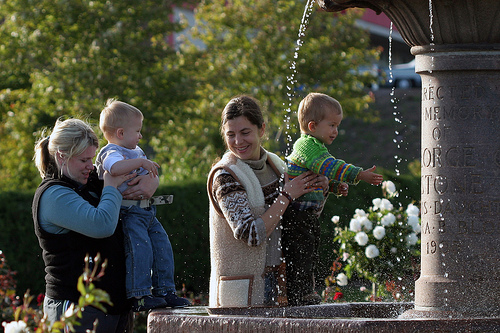

In [15]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255
PIL.Image.open(str(flowers_images_dict["roses"][1]))

In [17]:
num_classes = 5
model = Sequential([
layers.Conv2D(16, 3, padding='same', activation='relu'),
layers.MaxPooling2D(2,2),
layers.Dropout(0.5),
layers.Conv2D(32, 3, padding='same', activation='relu'),
layers.MaxPooling2D(2,2),
layers.Conv2D(64, 3, padding='same', activation='relu'),
layers.MaxPooling2D(2,2),
layers.Flatten(),
layers.Dense(128, activation='relu'),
layers.Dense(num_classes)
])
model.compile(optimizer='adam',
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy'])
model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.2406 - loss: 2.5926
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.4503 - loss: 1.3042
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.6157 - loss: 1.0066
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.6907 - loss: 0.8271
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.7492 - loss: 0.6762


In [18]:
model.evaluate(X_test_scaled,y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 328ms/step - accuracy: 0.5787 - loss: 1.0561


[1.1533265113830566, 0.5326975584030151]

In [19]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(224, 224, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.Dropout(0.5),
  layers.MaxPooling2D(2,2),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(2,2),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(2,2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.3050 - loss: 1.9053
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.5344 - loss: 1.1199
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.6049 - loss: 0.9797
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.6288 - loss: 0.9338
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.6777 - loss: 0.8256


In [21]:
model.evaluate(X_test_scaled,y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 310ms/step - accuracy: 0.4797 - loss: 1.2124


[1.2681596279144287, 0.46730244159698486]

In [22]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
pre_trained_model = hub.KerasLayer(feature_extractor_model, input_shape=(180,180,3), trainable=False)

In [23]:
modelv2 = Sequential([
  keras.Input(shape=(224, 224, 3)),
  data_augmentation,
  keras.layers.Lambda(lambda x: hub.KerasLayer(feature_extractor_model)(x)),
  layers.Dense(num_classes)
])
modelv2.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
modelv2.fit(X_train_scaled, y_train, epochs = 5)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.5504 - loss: 1.1320
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.8283 - loss: 0.4877
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.8673 - loss: 0.3974
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.8784 - loss: 0.3436
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9001 - loss: 0.3253


In [24]:
modelv2.evaluate(X_test_scaled,y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.8417 - loss: 0.4227


[0.4277299642562866, 0.8555858135223389]